# AbSynth Positional Perplexity Scan

End-to-end demo of `scan_evaluate.py` + `plot_scan.py` using AbSynth-A.

**Mode A — Synthetic data** (no model required): generates a realistic HDF5 file and plots it.  
**Mode B — Real model** (requires AbSynth-A): runs the actual scan on sample sequences.

Set `USE_REAL_MODEL = True` in Cell 2 to switch to Mode B.

## Cell 1 — Imports & paths

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # must be set before torch/numpy/etc. are imported

import sys
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# Resolve paths relative to notebook location (this notebook lives at repo root)
REPO_ROOT      = os.path.abspath(".")
MODEL_PATH     = os.path.join(REPO_ROOT, "absynth", "trained_models", "absynth-a")
TOKENIZER_PATH = os.path.join(REPO_ROOT, "absynth", "tokenizer")
OUTPUT_DIR     = "scan_output"
H5_PATH        = os.path.join(OUTPUT_DIR, "losses.h5")

os.makedirs(OUTPUT_DIR, exist_ok=True)
sys.path.insert(0, REPO_ROOT)

print(f"Repo root    : {REPO_ROOT}")
print(f"Model path   : {MODEL_PATH}")
print(f"Tokenizer    : {TOKENIZER_PATH}")

Repo root    : c:\Users\User\OneDrive\Desktop\PyProject\github-repo
Model path   : c:\Users\User\OneDrive\Desktop\PyProject\github-repo\absynth\trained_models\absynth-a
Tokenizer    : c:\Users\User\OneDrive\Desktop\PyProject\github-repo\absynth\tokenizer


## Cell 2 — Mode selector

In [2]:
USE_REAL_MODEL = False   # Set True to run AbSynth-A forward passes
MASK_LEN       = 10      # Window size for the positional scan
MIN_SAMPLES    = 50      # Positions with fewer samples are masked in the plot

print(f"Mode: {'Real AbSynth-A model' if USE_REAL_MODEL else 'Synthetic data (fast demo)'}")

Mode: Synthetic data (fast demo)


## Cell 3 — Sample antibody sequences

These are the sequences the scan will run on. Replace with your own CSV or add more sequences.

In [3]:
SAMPLE_SEQUENCES = [
    {
        "hseq": "EVQLVQSGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLEWVSAISGSGGSTYYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDREDIVVVPAPRGYYYYYYMDVWGQGTTVTVSS",
        "lseq": "DIQTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKLLIYAASSLQSGVPSRFSGSGSGTDFTLTISSLQPEDFATYYCQQSYSTPRTFGQGTKVEIK",
    },
    {
        "hseq": "EVQLESGGGLVQPGGSLRLSCAASGFPFNNYGMSWVRQAPGKGLEWVSIITGSGGSADYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARAVYSGSFLLDFWGQGTLVTVSS",
        "lseq": "EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRLLIYDASNRATGIPARFSGSGSGTDFTLTISSLEPEDFAVYYCQQSSNWPRTFGQGTKVEIK",
    },
    {
        "hseq": "EVQVESGGGLVQPGRSLRLSCTSPRFTFVDYAMSWVGQAPGKGLEWVGFIRSKAYGGTTEYAASVKGRFTISRDDSKSIAYLQMNSLKTEDTAVYYCTRDVSGLGQAPRFDYWGQGTLVTVSS",
        "lseq": "DIQMTQSPSSLSASVGDRVTITCRASQGIRNDLGWYQQKPGKAPKRLIYAASNLQSGVPSRFSGSGSGTEFTLTISSLQPEDFATYYCQQYNSYPWTFGQGTKVEIK",
    },
]

df = pd.DataFrame(SAMPLE_SEQUENCES)
CSV_PATH = os.path.join(OUTPUT_DIR, "sample_sequences.csv")
df.to_csv(CSV_PATH, index=False)
print(f"Saved {len(df)} sequence pairs → {CSV_PATH}")
df

Saved 3 sequence pairs → scan_output\sample_sequences.csv


,hseq,lseq
0,EVQLVQSGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...,DIQTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKLL...
1,EVQLESGGGLVQPGGSLRLSCAASGFPFNNYGMSWVRQAPGKGLEW...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...
2,EVQVESGGGLVQPGRSLRLSCTSPRFTFVDYAMSWVGQAPGKGLEW...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNDLGWYQQKPGKAPKR...


## Cell 4A — Synthetic scan (Mode A)

Generates a realistic HDF5 file without loading the model. Skipped in Mode B.

In [4]:
if not USE_REAL_MODEL:
    np.random.seed(42)

    HEAVY_LEN = 120
    LIGHT_LEN = 107
    N_SAMPLES  = 200

    # Approximate CDR positions (Kabat)
    heavy_cdrs = [(26, 35), (50, 66), (95, 102)]
    light_cdrs = [(24, 34), (50, 56), (89, 97)]

    def _synthetic_loss(length, cdr_positions, n):
        base = np.random.normal(1.5, 0.2, (n, length))
        for s, e in cdr_positions:
            base[:, s:e] += np.random.normal(1.0, 0.3, (n, e - s))
        avg = base.mean(axis=0).astype(np.float32)
        counts = np.full(length, n, dtype=np.float32)
        counts[:3] = counts[-3:] = 30   # sparse ends → will be masked
        return avg, counts

    hl, hn = _synthetic_loss(HEAVY_LEN, heavy_cdrs, N_SAMPLES)
    ll, ln = _synthetic_loss(LIGHT_LEN, light_cdrs, N_SAMPLES)

    with h5py.File(H5_PATH, "w") as f:
        f.create_dataset("Heavy_losses",              data=hl)
        f.create_dataset("Light_losses",              data=ll)
        f.create_dataset("Heavy_num_samples_per_pos", data=hn)
        f.create_dataset("Light_num_samples_per_pos", data=ln)

    print(f"Synthetic HDF5 saved → {H5_PATH}")
else:
    print("Mode B selected — skipping synthetic generation.")

Synthetic HDF5 saved → scan_output\losses.h5


## Cell 4B — Real model scan (Mode B)

Loads AbSynth-A and runs forward passes across all positions. Skipped in Mode A.

In [5]:
if USE_REAL_MODEL:
    import torch
    from collections import defaultdict
    from absynth import AbSynthA
    from analysis.scan_evaluate import build_scan_batch, compute_loss_per_sample

    absynth_a = AbSynthA(MODEL_PATH, TOKENIZER_PATH)
    model, tokenizer, device = absynth_a.model, absynth_a.tokenizer, absynth_a.device

    chain_losses = defaultdict(list)
    chain_pos    = defaultdict(list)

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Scanning sequences"):
        for chain, col in [("Heavy", "hseq"), ("Light", "lseq")]:
            batch = build_scan_batch(str(row[col]), tokenizer, MASK_LEN)
            with torch.no_grad():
                ids    = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)
                loss   = compute_loss_per_sample(
                    model(ids, labels=labels)["logits"], labels
                ).cpu().numpy()
            chain_losses[chain].append(loss)
            chain_pos[chain].append(np.arange(len(loss)))

    with h5py.File(H5_PATH, "w") as f:
        for chain in ["Heavy", "Light"]:
            all_loss = np.concatenate(chain_losses[chain])
            all_pos  = np.concatenate(chain_pos[chain])
            max_pos  = int(all_pos.max()) + 1
            loss_sum = np.zeros(max_pos)
            count    = np.zeros(max_pos)
            np.add.at(loss_sum, all_pos, all_loss)
            np.add.at(count,    all_pos, 1)
            f.create_dataset(f"{chain}_losses",              data=(loss_sum / count).astype(np.float32))
            f.create_dataset(f"{chain}_num_samples_per_pos", data=count.astype(np.float32))

    print(f"Scan complete → {H5_PATH}")
else:
    print("Mode A selected — skipping real model scan.")

Mode A selected — skipping real model scan.


## Cell 5 — Plot perplexity scan

Replicates `plot_scan.py` inline.

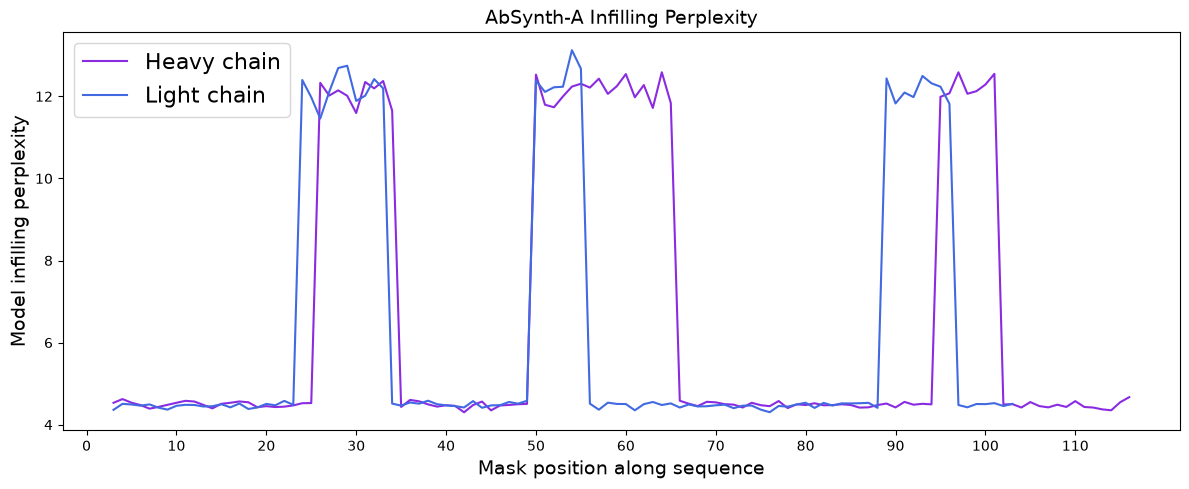

Plot saved → scan_output\scan.pdf


In [6]:
with h5py.File(H5_PATH, "r") as f:
    heavy_scores = np.array(f["Heavy_losses"])
    light_scores = np.array(f["Light_losses"])
    heavy_n      = np.array(f["Heavy_num_samples_per_pos"])
    light_n      = np.array(f["Light_num_samples_per_pos"])

# Loss → perplexity
heavy_scores = np.exp(heavy_scores)
light_scores = np.exp(light_scores)

# Mask sparse positions
heavy_scores[heavy_n <= MIN_SAMPLES] = np.nan
light_scores[light_n <= MIN_SAMPLES] = np.nan

plt.figure(figsize=(12, 5))
plt.plot(heavy_scores, color="blueviolet", label="Heavy chain")
plt.plot(light_scores, color="royalblue",  label="Light chain")
plt.legend(fontsize=16)

max_len = max(len(heavy_scores), len(light_scores))
skip_10 = np.arange(0, max_len, 10)
plt.xticks(skip_10, skip_10)

plt.ylabel("Model infilling perplexity", fontsize=14)
plt.xlabel("Mask position along sequence", fontsize=14)
plt.title("AbSynth-A Infilling Perplexity", fontsize=14)
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, "scan.pdf")
plt.savefig(out_path, dpi=400, transparent=True)
plt.show()
plt.close("all")
print(f"Plot saved → {out_path}")

## Cell 6 — Top high-perplexity positions

Shows which positions the model finds hardest to predict (likely CDR loops).

In [7]:
def top_positions(scores, label, top_n=5):
    valid = np.where(~np.isnan(scores))[0]
    top   = valid[np.argsort(scores[valid])[-top_n:][::-1]]
    print(f"{label} — top {top_n} highest-perplexity positions:")
    for pos in top:
        print(f"  position {pos:3d}  perplexity = {scores[pos]:.3f}")
    print()

top_positions(heavy_scores, "Heavy chain")
top_positions(light_scores, "Light chain")

Heavy chain — top 5 highest-perplexity positions:
  position  64  perplexity = 12.587
  position  97  perplexity = 12.586
  position 101  perplexity = 12.548
  position  60  perplexity = 12.542
  position  50  perplexity = 12.529

Light chain — top 5 highest-perplexity positions:
  position  54  perplexity = 13.124
  position  29  perplexity = 12.745
  position  28  perplexity = 12.690
  position  55  perplexity = 12.673
  position  93  perplexity = 12.497

